# 2. Event Definition


#### Discuss:
Add an explanation of the workflow
example color green needs user input, color yellow can be changed by the user, color red must not be touched by the user

In [1]:
# Imports
from c3s_lib import *
import requests
import urllib.parse
import matplotlib.pyplot as plt
import cartopy 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import json
import geopandas as gpd
import rasterio
from rasterio import features
from shapely.geometry import shape, Polygon, mapping, MultiPolygon, GeometryCollection
from shapely.vectorized import contains # replace with below
from shapely import contains_xy
import xarray as xr
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from shapely.ops import unary_union
from datetime import datetime, timedelta
import pandas as pd
import contextily as ctx
import math
import regionmask
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import cmocean
import base64
from io import BytesIO
import contextily as ctx
from typing import Union, Literal
import os


## 2.1 Choice of parameter

### <font color='orange'>Please specify the following variables below to start the workflow</font>

In [2]:
# Api key used for the DataClient, replace with your own API key from the C3S Climate Data Store
your_api_key = '98256e82-4de4-4cc1-8087-faebb5c2e4ae'

# Directory you wish to store output files in. using ../ specifies the parent directory
CURRENT_DIRECTORY = os.getcwd() # do not touch, __file__ specifies the current directory of the file
your_save_directory = os.path.join(CURRENT_DIRECTORY, "../data") # change ../data to your desired directory

# Area of interest (min lon, min lat, max lon, max lat)
bbox = (-110, 18, -95, 32)

# Date of the event
event_end = datetime(2024, 6, 7)
 # Date of days leading up to the event
event_start = event_end - timedelta(days=14)

# Choice of parameter (Tmax, Tmean, Tmin, Precipitation)
parameter = "Tmean"

# Unit
y_label = "c"

## 2.2.a.i Obtaining climatology (daily values) for period 1950 - event for chosen parameter

### Run code block

In [3]:
# climatology_1950_event = DataClient(your_api_key, beacon_cache_url='https://beacon-development.maris.nl').temperature_2m_mean(bbox, (datetime(1951, 1, 1), event_date))
gr_daily = DataClient(your_api_key, beacon_cache_url='https://beacon-development.maris.nl').GET(parameter=parameter, bbox=bbox, time_range=(datetime(1951,1,1), event_end), to_unit=y_label)
gr_daily.head()

Connected to: https://beacon-development.maris.nl/ server successfully
Connected to: https://beacon-development.maris.nl/ server successfully
Fetching data from beacon cache...
Beacon Bbox: (250.0, 18, 265.0, 32)
Running query: {"from": "era5_daily_mean_2m_temperature", "select": [{"column": "longitude", "alias": null}, {"column": "latitude", "alias": null}, {"column": "valid_time", "alias": null}, {"column": "t2m", "alias": null}], "filters": [{"and": [{"column": "longitude", "gt_eq": 250.0, "lt_eq": null}, {"column": "longitude", "gt_eq": null, "lt_eq": 265.0}, {"column": "latitude", "gt_eq": 18, "lt_eq": null}, {"column": "latitude", "gt_eq": null, "lt_eq": 32}]}, {"column": "valid_time", "gt_eq": "1951-01-01T00:00:00.000000", "lt_eq": "2024-06-07T00:00:00.000000"}], "output": {"format": "parquet"}}
Beacon cache covers time range: 1951-01-01 00:00:00 - 2024-06-07 00:00:00


,longitude,latitude,valid_time,t2m,geometry
0,-110.0,18.00,1951-01-01,23.174316,POINT (-110 18)
1,-110.0,18.25,1951-01-01,23.179443,POINT (-110 18.25)
2,-110.0,18.50,1951-01-01,23.130859,POINT (-110 18.5)
3,-110.0,18.75,1951-01-01,23.048492,POINT (-110 18.75)
4,-110.0,19.00,1951-01-01,22.917786,POINT (-110 19)


### <font color='orange'>Please specify the (geo) dataframe columns below</font>

In [4]:
# Value column. Can be overwritten by user
value_col = get_value_col(parameter)

# Datetime column
datetime_col = 'valid_time'

print ("selected value column:", value_col)
print ("selected datetime column:", datetime_col)

selected value column: t2m
selected datetime column: valid_time


## 2.2.a.i Select Subsets

### Run code block

In [5]:
# Sort gdf, this is needed when the era5 set gets merged with the beacon set
gr_daily = gr_daily.sort_values(by=datetime_col)

# Specifiy climatology dates
clim_start = datetime(1991, 1, 1)
clim_end = datetime(2020, 12, 31)

# Select event subset
gr_daily_eventNdays = subset_gdf(gdf=gr_daily, datetime_col=datetime_col, date_range=(event_start, event_end))

# Select climatology subset
gr_clim_eventNdays = subset_gdf(gdf=gr_daily, datetime_col=datetime_col, date_range=(clim_start, clim_end))

# needs a better print of the resulting dataframes
print(gr_clim_eventNdays)
print(gr_daily_eventNdays)

          longitude  latitude valid_time        t2m            geometry
50801289     -100.0     27.75 1991-01-01   9.296753  POINT (-100 27.75)
50801288     -100.0     27.50 1991-01-01   9.264465   POINT (-100 27.5)
50801287     -100.0     27.25 1991-01-01   9.330139  POINT (-100 27.25)
50801286     -100.0     27.00 1991-01-01   9.323059     POINT (-100 27)
50801281     -100.0     25.75 1991-01-01  10.110168  POINT (-100 25.75)
...             ...       ...        ...        ...                 ...
88897618     -105.0     22.75 2020-12-31   7.567627  POINT (-105 22.75)
88897617     -105.0     22.50 2020-12-31   8.966492   POINT (-105 22.5)
88897616     -105.0     22.25 2020-12-31  11.049011  POINT (-105 22.25)
88897615     -105.0     22.00 2020-12-31  13.906586     POINT (-105 22)
88897619     -105.0     23.00 2020-12-31   5.122070     POINT (-105 23)

[38100966 rows x 5 columns]
          longitude  latitude valid_time        t2m            geometry
93210259     -100.0     28.00 2024-

## 2.2.a.i Plotting figure of 15 maps for 15 days up to and including the event of the chosen variable.

### <font color='orange'>Specify the title for the plot</font>

In [6]:
title = 'Mean temperature (°C)'

### Run code block

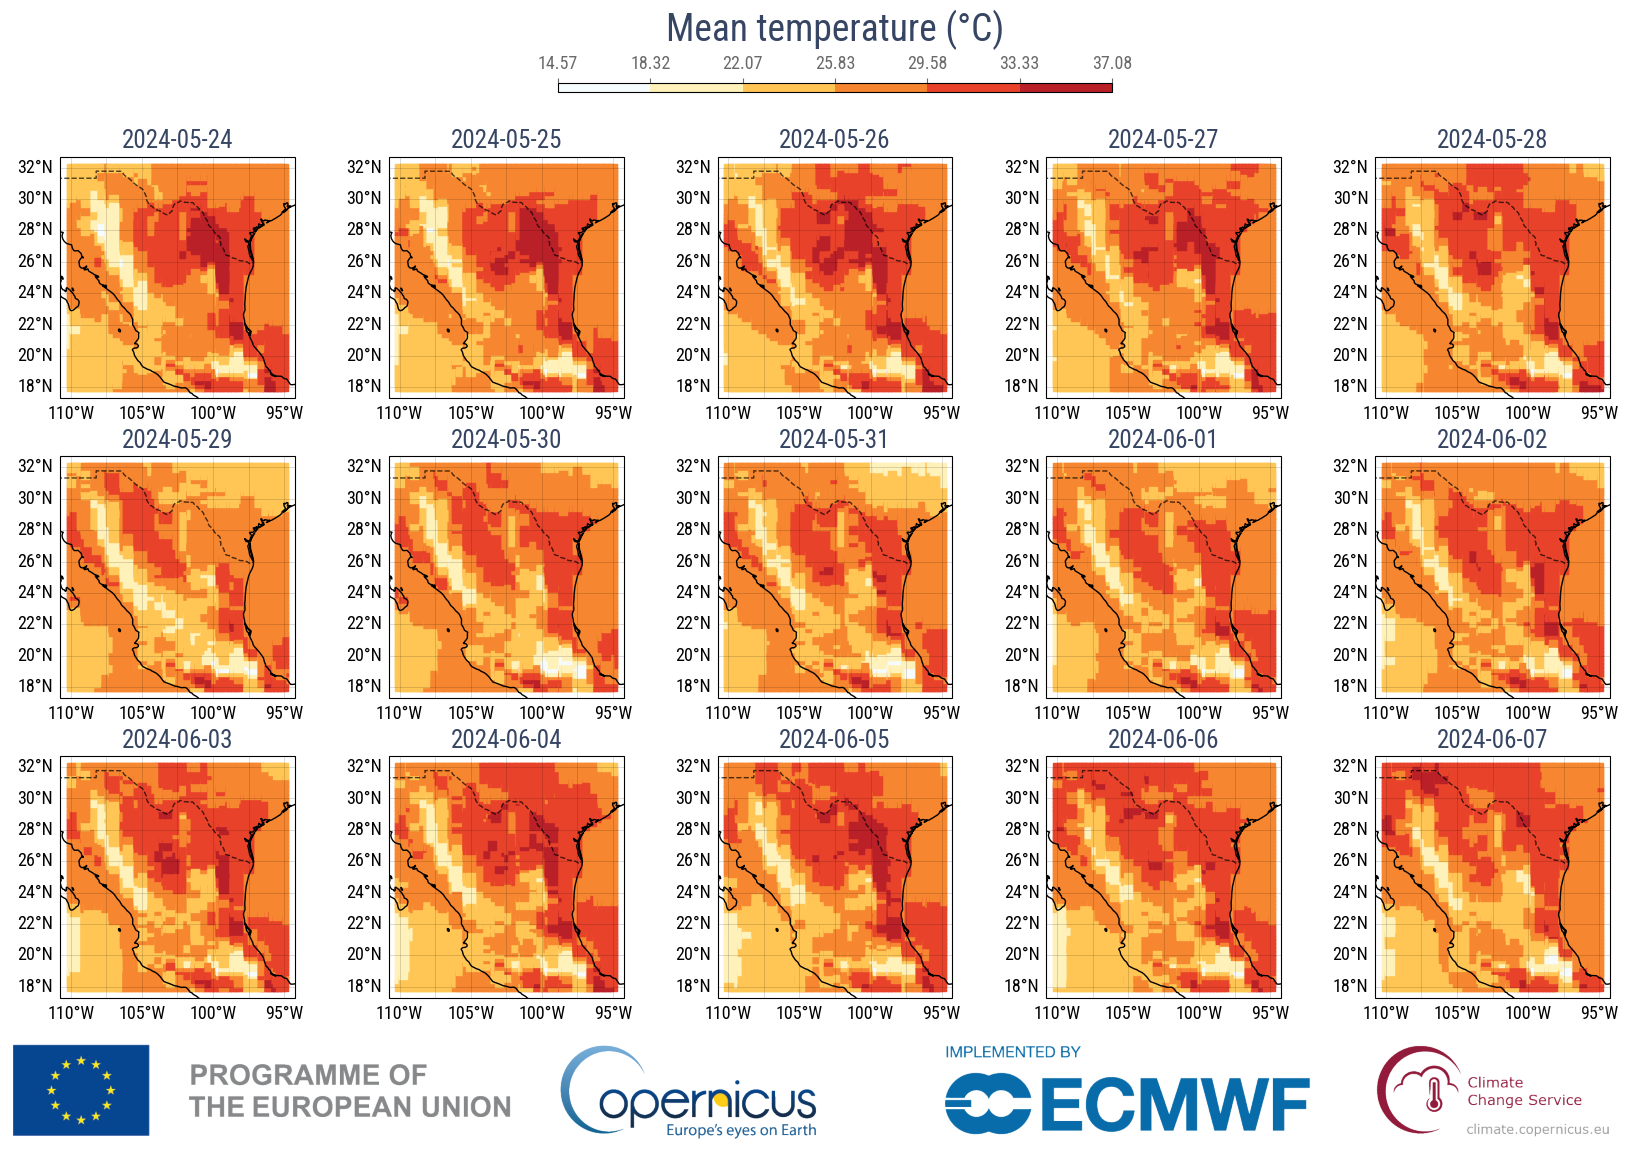

In [7]:
fig, axes, img_ax = subplot_gdf(gr_daily_eventNdays, datetime_col=datetime_col, value_col=value_col, ncols=5, legend_title=title)

## 2.2.a.ii Calculating the 30-day smoothed climatology for 1991-2020 and slicing out the event days

### <font color='orange'>Please specify name for saving the climatology to a file</font>

In [8]:
climatology_save = 'climatology_1991-2020'

### Run code block

In [9]:
# Calculate 30 smoothed mean for 1991-2020
clim31d = calculate_climatology(gr_clim_eventNdays, value_col=value_col, padding=15, event_date=event_end)

clim31d_eventNdays = subset_gdf(gdf=clim31d, datetime_col=datetime_col, doy_range=(event_start.timetuple().tm_yday, event_end.timetuple().tm_yday))
clim31d_eventNdays

,longitude,latitude,t2m,doy,geometry,valid_time
500688,-110.0,18.00,23.953434,145,POINT (-110 18),2024-05-24
500689,-110.0,18.25,23.766436,145,POINT (-110 18.25),2024-05-24
500690,-110.0,18.50,23.582802,145,POINT (-110 18.5),2024-05-24
500691,-110.0,18.75,23.381704,145,POINT (-110 18.75),2024-05-24
500692,-110.0,19.00,23.176945,145,POINT (-110 19),2024-05-24
...,...,...,...,...,...,...
552838,-95.0,31.00,26.707762,159,POINT (-95 31),2024-06-07
552839,-95.0,31.25,26.600462,159,POINT (-95 31.25),2024-06-07
552840,-95.0,31.50,26.477228,159,POINT (-95 31.5),2024-06-07
552841,-95.0,31.75,26.372051,159,POINT (-95 31.75),2024-06-07


In [10]:
# Save the data
clim31d.to_file(os.path.join(your_save_directory, f"{climatology_save}.gpkg"), layer='climatology', driver='GPKG')

## 2.2.a.ii Plotting figure of 15 maps for 15 days up to and including the event of the chosen variable's anomaly with respect to the 1991-2020 30-day running mean of the daily climatology.

### <font color='orange'>Please specify title for the plot</font>

In [11]:
title='Mean temperature anomaly (°C)'

# absolute for temperature, relative for precipitation
calculation = 'absolute'

### Run code block

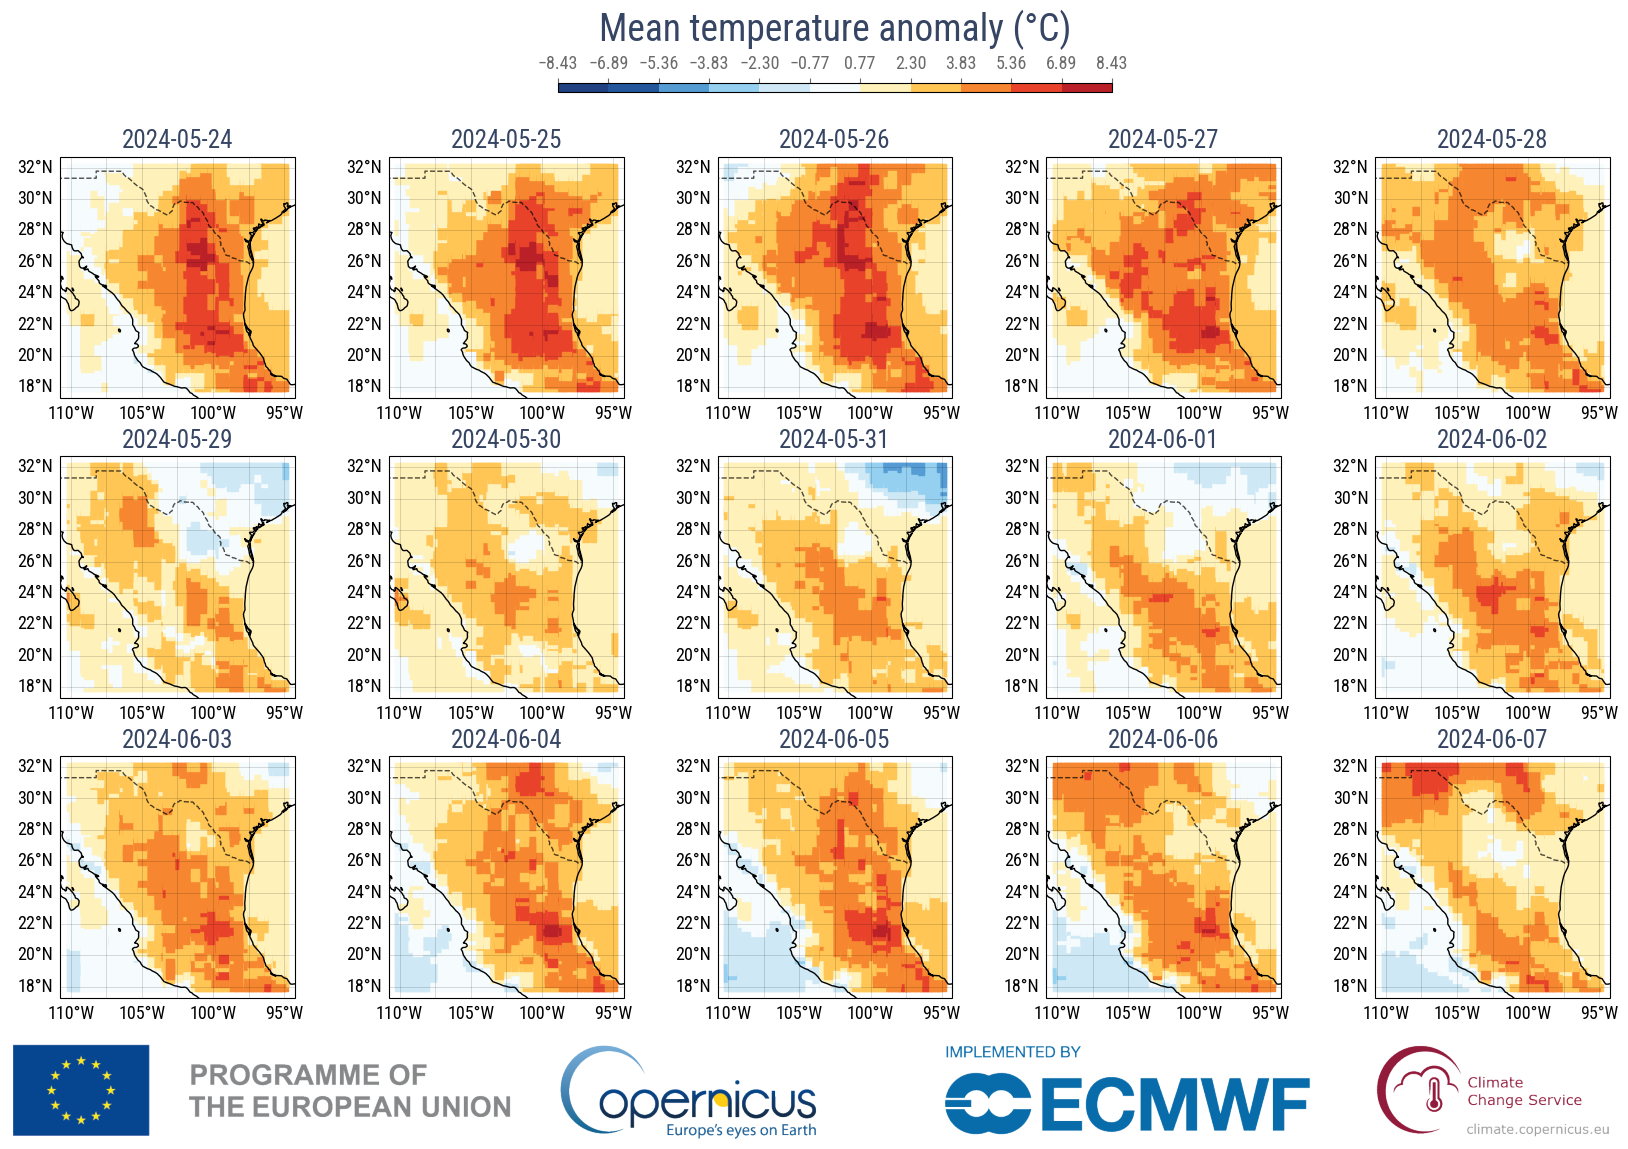

In [12]:
# Calculate the anomoly for the days leading up to the event
gr_anom_eventNdays = calculate_anomaly(event_gdf=gr_daily_eventNdays, mean_climatology_gdf=clim31d_eventNdays, value_col=value_col, datetime_col=datetime_col, calcation=calculation)
fig, axes, img_ax = subplot_gdf(gr_anom_eventNdays,datetime_col=datetime_col, value_col=value_col, ncols=5, legend_title=title)

### <font color='orange'>2.2.b Choose one day for the overlay of the regions in steps 2c-2g.</font>

In [13]:
# Selected date
selected_date = datetime(2024, 5, 26)

### <font color='orange'>2.2.c & 2.2.d Define type of region and level by visually inspecting the single map over the event region and select regions to be combined into one spatial event definition.</font>

In [14]:
# Overlay images
anomaly_img = get_base_fig(selected_date, gr_anom_eventNdays, value_col=value_col)      # Anomaly
event_img = get_base_fig(selected_date, gr_daily_eventNdays, value_col=value_col)  # Event
overlays = {
    "anomaly": anomaly_img,
    "event": event_img
}
# regiontype wraf for temperature, hydrobasin for precipitation
region_type = 'wraf'

### Run code block and select a region in the region picker that opens in the browser

The region picker will shortly open in your web browser. Please select a region, close the browser tab and return to the notebook when done.
Region Picker started successfully for wraf:
Polling for region selection...
Region selection process done.
Received polygon data:
{"type":"FeatureCollection","features":[{"type":"Feature","properties":{"merge_key":"1"},"geometry":{"type":"Polygon","coordinates":[[[-104.292,22.2917],[-104.208,22.2917],[-104.208,22.3333],[-104.042,22.3333],[-104.042,22.375],[-103.958,22.375],[-103.958,22.4583],[-103.917,22.4583],[-103.917,22.5],[-103.958,22.5],[-103.958,22.5417],[-104,22.5417],[-104,22.7917],[-103.958,22.7917],[-103.958,22.75],[-103.792,22.75],[-103.792,22.5833],[-103.833,22.5833],[-103.833,22.5],[-103.875,22.5],[-103.875,22.2083],[-103.833,22.2083],[-103.833,22.3333],[-103.792,22.3333],[-103.792,22.5417],[-103.75,22.5417],[-103.75,22.625],[-103.708,22.625],[-103.708,22.5833],[-103.625,22.5833],[-103.625,22.4583],[-103.667,22.4583],[-103.667,22.125

c:\Python310\lib\site-packages\xarray\coding\times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 0:0:0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 0:0:0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
C:\Users\jasper\AppData\Local\Temp\ipykernel_34408\228881419.py:6: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  elevation_nc = xr.open_dataset("../data/elev.0.25-deg.nc")


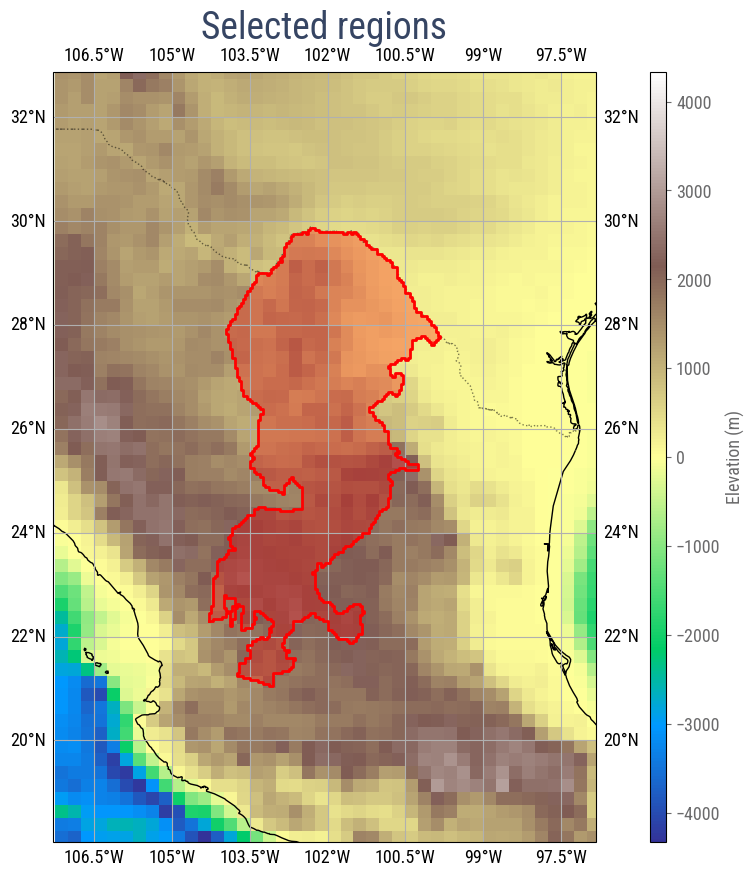

In [15]:
result = select_region(regionType=region_type, bbox=bbox, overlays=overlays) 
data = json.loads(result)

polygons, coords = data_2_poly(data)

elevation_nc = xr.open_dataset("../data/elev.0.25-deg.nc")
elevation = wrap_lon(elevation_nc)['data']

fig, ax = plot_poly(polygons, coords, elevation=elevation)

## 2.2.e Use topography overlay to decide whether to cut off area above a specified height level

### <font color='orange'>Please select an elevation threshold</font>

In [16]:
# the studyregion is selected as all areas below the elevation threshold
elevation_threshold = 2000  # meters

### Run code block

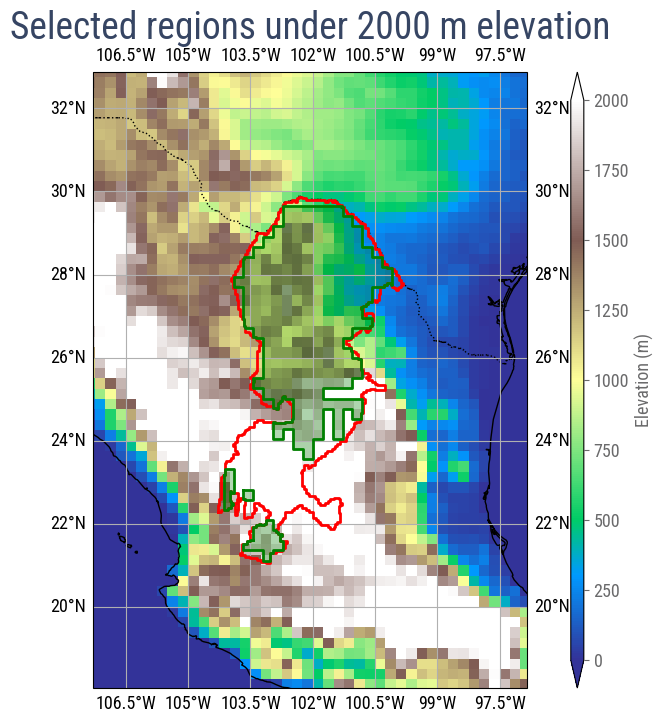

In [17]:
# The adjusted_polygons are later used for visualizing the studyregion in the plots
fig, ax, adjusted_polygons = elevation_region(data, polygons, elevation, elevation_threshold)

## 2.3 Save study domain for use in other parts of the software


### <font color='orange'>Please specify name for saving the study region</font>

In [18]:
shapefile_save = "sf_studyregion"

### Run code block

In [19]:
# the studyregion is used for masking the geospatial data
multipoly = unary_union(adjusted_polygons)
studyregion = gpd.GeoDataFrame(index=[0], crs='EPSG:4326', geometry=[multipoly])    #is this using the correct CRS?
studyregion.to_file(os.path.join(your_save_directory, f"{shapefile_save}.shp"))
#polygons_gdf = gpd.GeoDataFrame(geometry=polygons, crs="EPSG:4326")
#polygons_gdf.to_file("../data/sf_polygons.shp")

## 2.4 Create daily time series of the required variable by averaging over the study domain

### <font color='orange'>Please specify name for saving the climatology timeseries</font>

In [20]:
daily_timeseries_save = "ts_daily_studyregion"

### Run code block

In [21]:
# climatology_1950_event_studyregion = gpd.overlay(climatology_1950_event, studyregion, how='intersection')
gr_daily_studyregion = subset_gdf(gdf=gr_daily, study_region=studyregion)

# give eacht cell a weight based on its size (latitude related)
gr_daily_studyregion_weighted = weighted_values(gr_daily_studyregion, value_col)

# calculate spatial mean
ts_daily_studyregion = calculate_mean(gdf= gr_daily_studyregion_weighted,
                                                                value_col=value_col, groupby_col=datetime_col)

#spatialmean_climatology_1950_event_studyregion = climatology_1950_event_studyregion.groupby(datetime_col)[value_col].mean().reset_index()
ts_daily_studyregion.to_xarray().to_netcdf(f"{your_save_directory}/{daily_timeseries_save}.nc")
ts_daily_studyregion

,valid_time,t2m
0,1951-01-01,14.584808
1,1951-01-02,16.198125
2,1951-01-03,9.628332
3,1951-01-04,11.119111
4,1951-01-05,12.857681
...,...,...
26817,2024-06-03,30.045088
26818,2024-06-04,30.579881
26819,2024-06-05,31.033228
26820,2024-06-06,29.393746


## 2.5 Compare n-day accumulations (precipitation) or n-day averages (temperature) for the current year to the seasonal cycle of the same

### <font color='orange'>Please specify the variables below</font>

In [22]:
# n-days
# temperature (t2m): days = [1, 3, 7, 14] & precipitation (tp): days = [1, 3, 5, 10]
days = [1, 3, 5, 10] if value_col is 'tp' else [1, 3, 7, 14]

# method: mean, sum, std, quantile
method = 'mean'
centering = False

# if method quantile is selected
quantile = .9

title = 'average temperature'

y_limit = None

<>:3: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:3: SyntaxWarning: "is" with a literal. Did you mean "=="?
C:\Users\jasper\AppData\Local\Temp\ipykernel_34408\1990555942.py:3: SyntaxWarning: "is" with a literal. Did you mean "=="?
  days = [1, 3, 5, 10] if value_col is 'tp' else [1, 3, 7, 14]


### Run code block

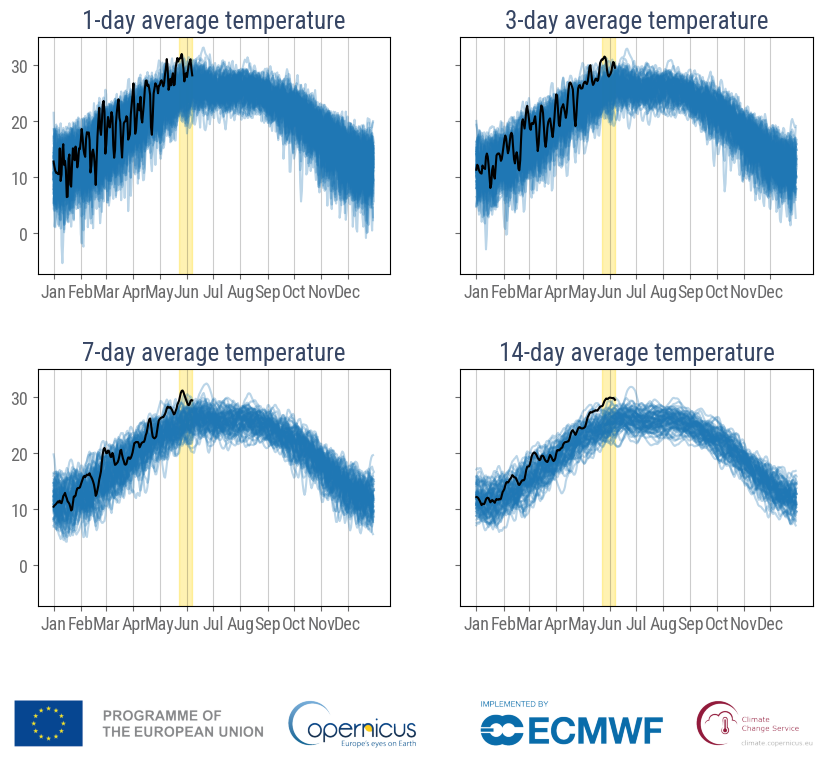

In [23]:
# calculate n-day rolling values
rolled_data_list = [calculate_rolling_n_days(gdf=ts_daily_studyregion,
                                            value_col=value_col, datetime_col=datetime_col,
                                            padding=d, centering=centering, method=method, quantile=quantile) for d in days]

# labels and label ticks
labelticks = pd.date_range("2000-01-01", "2000-12-31", freq="MS").dayofyear
labels = pd.date_range("2000-01-01", "2000-12-31", freq="MS").strftime("%b")

# plot timeseries
fig, axes, img_ax = plot_n_days(rolled_data_list, value_col=value_col, parameter=parameter,
                                event_date=event_end, labelticks=labelticks, labels=labels,
                                days=days, title=title, ylimit=y_limit, fig_height=4, ncols=2)

## 2.6 Calculate and plot seasonal cycle over years 1991-2020

### <font color='orange'>Please specify the following variables<font>

In [24]:
# plot title
title = 'Seasonal cycle temperature 1991-2020'

y_label = '(°C)'

month_range = (1, 12)

### Run code block

#### Seasonal cycle Januari-December

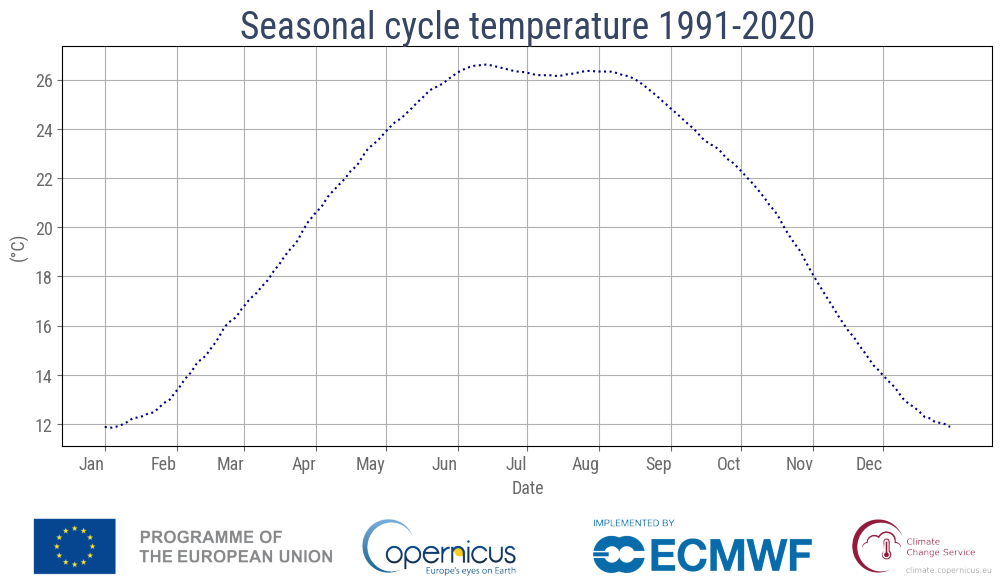

In [25]:
# select study region
gr_clim31d_studyregion = subset_gdf(gdf=clim31d, study_region=studyregion, month_range=month_range)
# recreate datetime column
gr_clim31d_studyregion[datetime_col] = pd.to_datetime(f'{event_end.year}', format='%Y') + pd.to_timedelta(gr_clim31d_studyregion['doy'] - 1, unit='D')

# give each value a weight based on its size (latitude related)
gr_clim31d_studyregion_weighted = weighted_values(gr_clim31d_studyregion, value_col)

# calculate spatial mean
ts_clim31d_studyregion = calculate_mean(gdf= gr_clim31d_studyregion_weighted,
                                                                value_col=value_col, groupby_col=datetime_col)

# get the plot values and labels
plot_df, labels, labelticks = get_seasonal_cycle_plot_values(data=ts_clim31d_studyregion, datetime_col=datetime_col, month_range=month_range,)

# plot the figure
fig, ax, img_ax= plot_timeserie(data=plot_df, value_col=value_col, title=title,
                                x_label='Date', y_label=y_label, line_style=':',
                                labels=labels, labelticks=labelticks)


#### Seasonal cycle July-June

In [26]:
# plot title
title = 'Seasonal cycle temperature July-June 1991-2020'

y_label = '(°C)'

month_range = (7, 6)

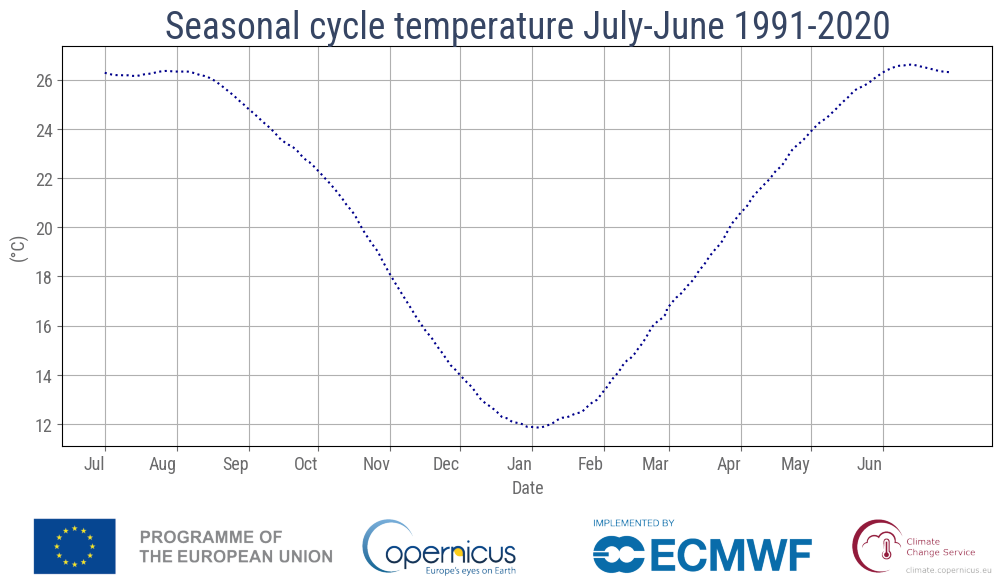

In [27]:
# select study region
gr_clim31d_studyregion = subset_gdf(gdf=clim31d, study_region=studyregion, month_range=month_range)
# recreate datetime column
gr_clim31d_studyregion[datetime_col] = pd.to_datetime(f'{event_end.year}', format='%Y') + pd.to_timedelta(gr_clim31d_studyregion['doy'] - 1, unit='D')

# give each value a weight based on its size (latitude related)
gr_clim31d_studyregion_weighted = weighted_values(gr_clim31d_studyregion, value_col)

# calculate spatial mean
ts_clim31d_studyregion2 = calculate_mean(gdf= gr_clim31d_studyregion_weighted,
                                        value_col=value_col, groupby_col=datetime_col)

# get the plot values and labels
plot_df, labels, labelticks = get_seasonal_cycle_plot_values(data=ts_clim31d_studyregion2, datetime_col=datetime_col, month_range=month_range,)

# plot the figure
fig2, ax, img_ax= plot_timeserie(data=plot_df, value_col=value_col, datetime_col="plot_time",
                                 title=title, x_label='Date', y_label=y_label, line_style=':',
                                 labels=labels, labelticks=labelticks)


### <font color='orange'>Please specify names for saving the dataframe and figure</font>

In [28]:
# time series save
seasonal_cycle_series_save = 'seasonal_cycle_1991-2020'

# figure save
seasonal_cycle_figure_save = 'seasonal_cycle_1991-2020'

### Run code block

In [29]:
# save the time serie
ds = xr.Dataset.from_dataframe(ts_clim31d_studyregion.set_index("valid_time"))
ds.to_netcdf(os.path.join(your_save_directory, f"{seasonal_cycle_series_save}.nc"))

# save the figure
fig.savefig(fname=os.path.join(your_save_directory, f"{seasonal_cycle_figure_save}.png"), dpi=150, bbox_inches="tight")

## 2.7 Decide on the temporal extent  
Use **Step 2.2** and the following considerations:

#### a. As much related to impacts as possible
- e.g. `TXx` (max Temperature 1-day, outdoor workers)  
- e.g. `T3x` (mean Temperature 3-day, people indoors)  
- e.g. Flooding: precipitation averaged over duration or over response time basin  
- e.g. Drought: precipitation values (or soil moisture) averaged over several months or multiple rainy seasons  

#### b. Seasonality
- **OPTIONAL:** Use information from literature review (see also Sec. 6a.), specifically for information on seasonality, that can feed into the choice of event definition.  
- Make use of seasonal cycle plot  
- Restrict to some months if necessary, e.g. if event occurred outside of the usual season or a change in seasonality is suspected  
  - Example: May–June maximum 4-day precipitation  
- Potentially take temperature anomalies rather than absolute values if averaging over months where the seasonal cycle is in transition between peaks and troughs  

#### c. Make use of the plots created in Step 2.5

## 2.8 Make a final decision on the event definition  
Update the output table in the tables document (apart from the last row on return period).

#### a. Write down in the Jupyter Notebook the factors that informed the specific event definition  
Use the following considerations as a guide to single out which aspect of the multifaceted nature of the extreme is chosen for emphasis and communication:

- **Variable:**  
  - `Tmax`, `Tmin`, or `Tmean` – were the daily maxima or the high nighttime minima or both the most defining for the heat event?  

- **Timing:**  
  - Is it the early-season onset of the event that made it anomalous (only) for the time of year, giving locals little time to adjust?  

- **Seasonality:**  
  - Is it specific for a single season only, in case of multiple peaks in the seasonal cycle?  

- **Duration:**  
  - Is it daily record-breaking extremes that will dominate headlines?  
  - Or the long persistence of heat that will also impact indoor conditions, drought, or fire weather, and be felt more than one day of exceptional heat?  

- **Spatial:**  
  - Is the large spatial extent of the event particularly noteworthy over other factors and in comparison to previous similar events in the region?  
  - Or is it that the event location coincides with a densely populated area that makes it particularly noteworthy?  

In [30]:
#number of days (maximum/mean/minimum of 3 day averages - couple of days from months around selection are needed)
#minimum/maximum / mean
#jan-dec, july-june, specific months (may-june only for example)

## 2.9 Create annual time series based on the event definition


### <font color='orange'>Please specify the following variables to calculate the annual time series</font>

In [31]:
# mean, max. min
yearly_value = 'max'

# padding >= 1 : rolling mean, rolling window, n-days (centered)
padding = 3

# (1, 12) V (12,1)
month_range = (5, 6)

title = 'May-June maximum temperature'

y_label = '(°C)'

line_style='-'

draw_style='steps'

### Run code block

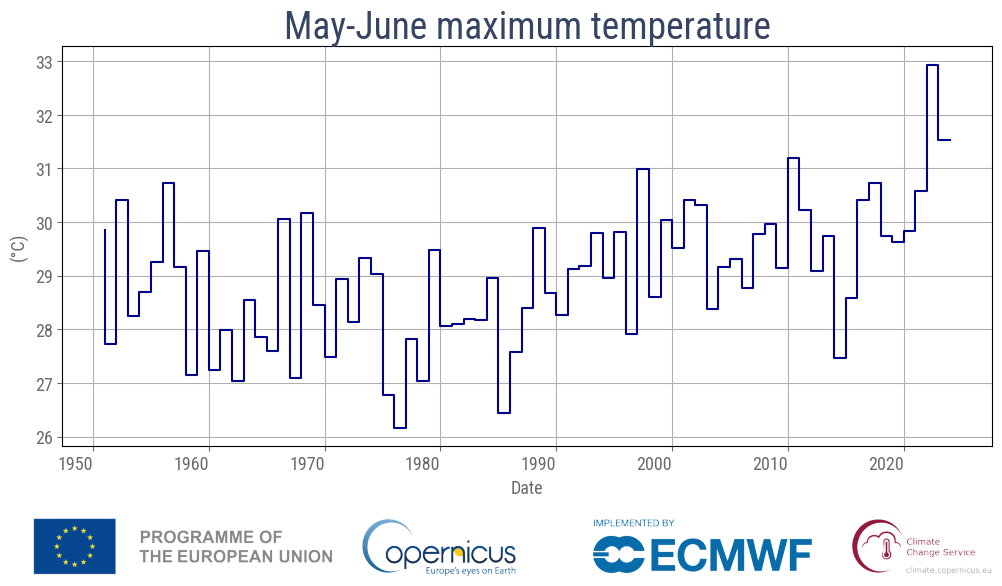

In [32]:
# # Optionally the juli-june yearly value can be calculated by shifting the dates by 6 months
# shifted_dates = shift_datetime_by_months(gdf=spatialmean_climatology_1950_event_studyregion,
#                                          datetime_col=datetime_col, shift_by=6, direction='backward')

# Example maximum 3 day running mean yearly maximum
ts_ann_studyregion = calculate_yearly_value(gdf=ts_daily_studyregion,
                                            value_col=value_col, datetime_col=datetime_col,
                                            yearly_value=yearly_value, padding=padding,
                                            month_range=month_range)

# plot
fig, ax, img_ax = plot_timeserie(data=ts_ann_studyregion, value_col=value_col,
                                 datetime_col='year', title=title, x_label='Date',
                                 y_label=y_label, line_style=line_style, draw_style=draw_style)

In [33]:
# mean, max. min
yearly_value = 'min'

# padding >= 1 : rolling mean, rolling window, n-days (centered)
padding = 3

# (1, 12) V (12,1)
month_range = (12, 1)

title = 'Dec-Jan minimum temperature'

y_label = '(°C)'

line_style='-'

draw_style='steps'

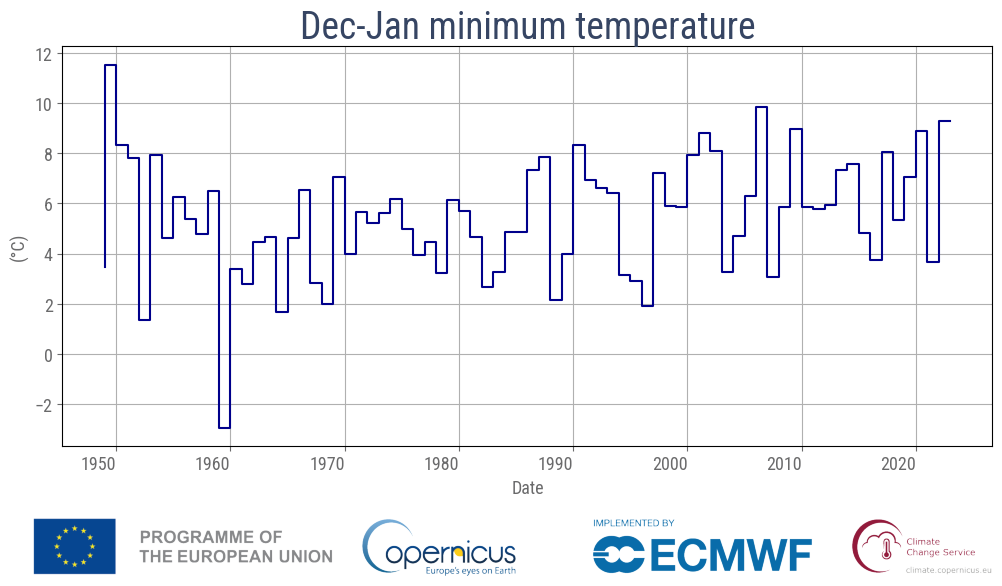

In [34]:
# # Optionally the juli-june yearly value can be calculated by shifting the dates by 6 months
# shifted_dates = shift_datetime_by_months(gdf=spatialmean_climatology_1950_event_studyregion,
#                                          datetime_col=datetime_col, shift_by=6, direction='backward')

# Example maximum 3 day running mean yearly maximum
ts_ann_studyregion = calculate_yearly_value(gdf=ts_daily_studyregion,
                                            value_col=value_col, datetime_col=datetime_col,
                                            yearly_value=yearly_value, padding=padding,
                                            month_range=month_range)

# plot
fig, ax, img_ax = plot_timeserie(data=ts_ann_studyregion, value_col=value_col,
                                 datetime_col='year', title=title, x_label='Date',
                                 y_label=y_label, line_style=line_style, draw_style=draw_style)

### Display peak date in the year of the event

In [35]:
# center date of the n-day average
print(ts_ann_studyregion[datetime_col][-1:])

74   2023-12-29
Name: valid_time, dtype: datetime64[ns]


### <font color='orange'>Please specify name for saving the annual time series</font>

In [36]:
annual_timeseries_save = 'ts_ann_studyregion'

### Run code block

In [37]:
ds = xr.Dataset.from_dataframe(ts_ann_studyregion.set_index("year"))
ds.to_netcdf(os.path.join(your_save_directory, f"{annual_timeseries_save}.nc"))

## 2.10 Read in station data time series from a CSV file

### <font color='orange'>Optionally load in data from a csv or xls file</font>

In [38]:
# # CSV
# separator = ','
# encoding = 'utf-8'
# file_name = 'my_file.csv'   # optionaly add directory
# df = pd.read_csv(file_name, sep=separator, encoding=encoding)

In [39]:
# XLS
# read station data time series from .xls
#xls_station_data = pd.ExcelFile("../data/example.xlsx")
#print(xls_station_data.sheet_names)   # list available sheets
#xls_station_data_sheet1 = pd.read_excel(xls_station_data, "Sheet1")
#xls_station_data_sheet2 = pd.read_excel(xls_station_data, "Sheet2")

In [40]:
#number of days (maximum/mean/minimum of 3 day averages - couple of days from months around selection are needed)
#minimum/maximum / mean
#jan-dec, july-june, specific months (may-june only for example)

## 2.11 Produce a figure of the anuual time series "Event Map" (averaged over the temporal definition)


### <font color='orange'>Please specify the following variables to plot the event and anomaly</font>

In [41]:
y_label = '(°C)'

# event
event_title = 'Mean temperature'
event_poly_col = 'cyan'

# anomaly
anomaly_title = 'Mean temperature anomaly'
anomaly_poly_col = 'lime'

# possible free user input for an input date + padding
# uncomment if you want to select a different date and/or padding
#selected_date = pd.to_datetime('2024-05-26')
#padding = 3

### Run code block

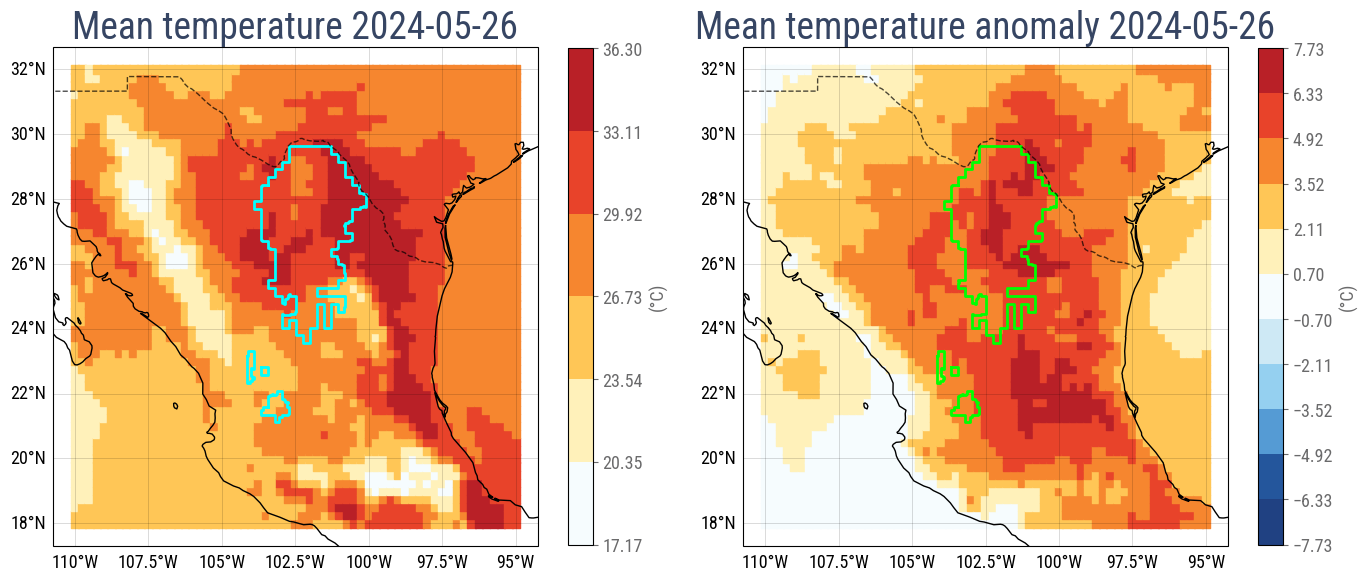

In [42]:
# verekenen met padding
selected_date = selected_date if selected_date else pd.to_datetime(ts_ann_studyregion[datetime_col].iloc[-1])

pad = math.floor(padding/2)
selected_date_start = selected_date - timedelta(days=pad)
selected_date_end = selected_date + timedelta(days=pad)

# event selection
selected_intersect = subset_gdf(gdf=gr_daily_eventNdays, datetime_col=datetime_col,
                                date_range=(selected_date_start, selected_date_end))
# anomaly selection
selected_intersect_anomaly = subset_gdf(gdf=gr_anom_eventNdays, datetime_col=datetime_col,
                                        date_range=(selected_date_start, selected_date_end))

# average
selected_event_mean = calculate_mean(gdf=selected_intersect, value_col=value_col, groupby_col=['longitude', 'latitude', 'geometry'])
selected_anomaly_mean = calculate_mean(gdf=selected_intersect_anomaly, value_col=value_col, groupby_col=['longitude', 'latitude', 'geometry'])

# create subplot
figs, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={"projection": ccrs.PlateCarree()})

# plot event
fig, ax = plot_gdf(selected_event_mean, value_col=value_col, ax=axes[0],
                     title=f"{event_title} {selected_date.strftime('%Y-%m-%d')}",
                     legend_title=y_label, add_logos=False, polygons=adjusted_polygons, polygon_color=event_poly_col)
# plot anomaly
fig, ax = plot_gdf(selected_anomaly_mean, value_col=value_col, ax=axes[1],
                     title=f"{anomaly_title} {selected_date.strftime('%Y-%m-%d')}",
                     legend_title=y_label, add_logos=False, polygons=adjusted_polygons, polygon_color=anomaly_poly_col)

plt.tight_layout()
plt.show()

## 2.12 Write a paragraph on the event definition in the scientific report Section 1.

## 2.13 Produce a set of maps of the meteorological situation for 15 days up to and including the event.

In [43]:
def subplot_contours(
    contour_gdf:gpd.GeoDataFrame, gdf:gpd.GeoDataFrame, value_col:str, contour_col:str,
    legend_title:str=None, datetime_col:str="valid_time",
    polygons:list[Polygon]=None, ncols:int=5, figsize:tuple[int,int]=(20,10),
    cmap:str|None=None, borders:bool=True, coastlines:bool=True, gridlines:bool=True,
    subtitle:str=None, extends:tuple[float,float,float,float]=None, dpi:int=100,
    flatten_empty_plots:bool=True, marker:str='s', shared_colorbar:bool=True,
    add_logos:bool=False, polygon_color:str='cyan', contour_steps:int=200,
    projection:cartopy.crs=ccrs.PlateCarree(), grid_line_col:str='gray', grid_line_size:float=.4,
    grid_line_alpha:float=.5
):
    """
    Plot daily values from a GeoDataFrame with Z500 contours from another GeoDataFrame.
    """

    # set cmap type
    cmap = cmap if cmap else value_col

    # Ensure datetime
    gdf[datetime_col] = pd.to_datetime(gdf[datetime_col])
    contour_gdf[datetime_col] = pd.to_datetime(contour_gdf[datetime_col])

    # Unique sorted days
    unique_days = sorted(contour_gdf[datetime_col].dt.date.unique())
    n_plots = len(unique_days)
    nrows = math.ceil(n_plots / ncols)

    # Projection fixed to LambertConformal
    mid_lon = contour_gdf["longitude"].mean()
    mid_lat = contour_gdf["latitude"].mean()
    proj = ccrs.LambertConformal(central_longitude=mid_lon, central_latitude=mid_lat)

    # Figure
    fig, axes = plt.subplots(
        nrows, ncols, figsize=figsize, dpi=dpi,
        subplot_kw={"projection": proj}
    )
    axes = axes.flatten()

    # Shared color scale
    if shared_colorbar:
        vmin = gdf[value_col].min()
        vmax = gdf[value_col].max()
        cmap, norm = get_colormap(cmap, vmin, vmax)
    else:
        norm = None

    # contour contour levels
    zmin, zmax = contour_gdf[contour_col].min(), contour_gdf[contour_col].max()
    z_lev = np.arange(round(zmin), round(zmax), contour_steps)

    for i, day in enumerate(unique_days):
        ax = axes[i]
        day_gdf = gdf[gdf[datetime_col].dt.date == day]

        if not shared_colorbar:
            vmin = day_gdf[value_col].min()
            vmax = day_gdf[value_col].max()
            cmap, norm = get_colormap(cmap, vmin, vmax)

        if not day_gdf.empty:
            day_gdf.plot(
                ax=ax, column=value_col, cmap=cmap,
                legend=False, vmin=vmin, vmax=vmax,
                norm=norm, marker=marker,
                transform=projection
            )

        # --- Z500 contours ---
        contour_day = contour_gdf[contour_gdf[datetime_col].dt.date == day]
        if not contour_day.empty:
            pivot = contour_day.pivot_table(index="latitude", columns="longitude", values=contour_col)
            lon, lat, Z = pivot.columns.values, pivot.index.values, pivot.values
            cn = ax.contour(lon, lat, Z, z_lev, colors="dimgray", linewidths=0.5, transform=projection)
            ax.clabel(cn, inline=1)

        if not shared_colorbar:
            # Add colorbar per axis
            #norm = cmap_norm_boundary(vmin, vmax, 11)
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            sm._A = []
            cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.04, pad=0.04, ticks=norm.boundaries)
            cbar.set_label(legend_title)

        # Map features

        if gridlines:
            gl = ax.gridlines(
                draw_labels=True, x_inline=False, y_inline=False,
                linewidth=grid_line_size, color=grid_line_col, alpha=grid_line_alpha
            )
            gl.right_labels = gl.top_labels = False
            # gl.xlabel_style = {"size": 8, "color": grid_line_col}
            # gl.ylabel_style = {"size": 8, "color": grid_line_col}

        if coastlines:
            ax.coastlines(resolution="50m", color="black", linewidth=0.5, alpha=0.7)
        if borders:
            ax.add_feature(cfeature.BORDERS, lw=0.5, alpha=0.7, color="black")

        if polygons is not None:
            for poly in polygons:
                x, y = poly.exterior.xy
                ax.plot(x, y, color=polygon_color, linewidth=2, transform=projection)

        ax.set_title(f"{day}", fontsize=18, weight='medium')

        if extends is not None:
            ax.set_extent(extends, crs=projection)


    fig.subplots_adjust(hspace=.8)

    # Hide empty plots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(not flatten_empty_plots)

    # Shared colorbar
    if shared_colorbar:
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm._A = []        
        cbar = fig.colorbar(sm, ax=axes.tolist(), orientation='horizontal', location="top",
                            fraction=0.01, pad=.07, aspect=60, ticks=norm.boundaries)
        cbar.set_label(legend_title if legend_title else value_col,
                       labelpad=10, fontsize=27, weight='bold', color='#364563')
        plt.setp(plt.getp(cbar.ax.axes, 'xticklabels'), family=roboto_condensed_regular.get_name(), fontsize=13)
        plt.show()

    if subtitle:
        fig.suptitle(subtitle, y=1.05)

    # fig.subplots_adjust(wspace=0.25, hspace=.45, top=.85)

    if add_logos:
        plt.close(fig)
        fig, img_ax = add_image_below(fig=fig, image_path=logo_horizon_path, pad_frac=-0.1)
        return fig, axes, img_ax
    else:
        return fig, axes


### <font color='orange'>Please specify the following variables</font>

In [44]:
parameter = 'z500'

contour_steps = 250

# z for z500, msl for slp
contour_col = 'z'

legend_title = 'ERA5 Z500 and T2M'

In [45]:
contour_gdf = DataClient(your_api_key, beacon_cache_url='https://beacon-development.maris.nl').GET(parameter=parameter, bbox=bbox, time_range=(event_start, event_end))
print(contour_gdf.head())

Connected to: https://beacon-development.maris.nl/ server successfully
Connected to: https://beacon-development.maris.nl/ server successfully


2025-10-09 14:09:20,340 INFO Request ID is c2bc72ef-821e-4735-b053-f0d76ac643a0
2025-10-09 14:09:20,416 INFO status has been updated to accepted
2025-10-09 14:09:28,901 INFO status has been updated to running
2025-10-09 14:09:34,070 INFO status has been updated to successful


9a2e215f1ac767d324944cabf2f74130.nc:   0%|          | 0.00/211k [00:00<?, ?B/s]

    pressure_level  latitude  longitude valid_time             z  number  \
7            500.0      32.0     -110.0 2024-05-24  56991.933594       0   
8            500.0      32.0     -110.0 2024-05-25  56902.613281       0   
9            500.0      32.0     -110.0 2024-05-26  57086.488281       0   
10           500.0      32.0     -110.0 2024-05-27  57410.968750       0   
11           500.0      32.0     -110.0 2024-05-28  57558.253906       0   

           geometry  
7   POINT (-110 32)  
8   POINT (-110 32)  
9   POINT (-110 32)  
10  POINT (-110 32)  
11  POINT (-110 32)  


c:\Python310\lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
c:\Python310\lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
c:\Python310\lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
c:\Python310\lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
c:\Python310\lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecol

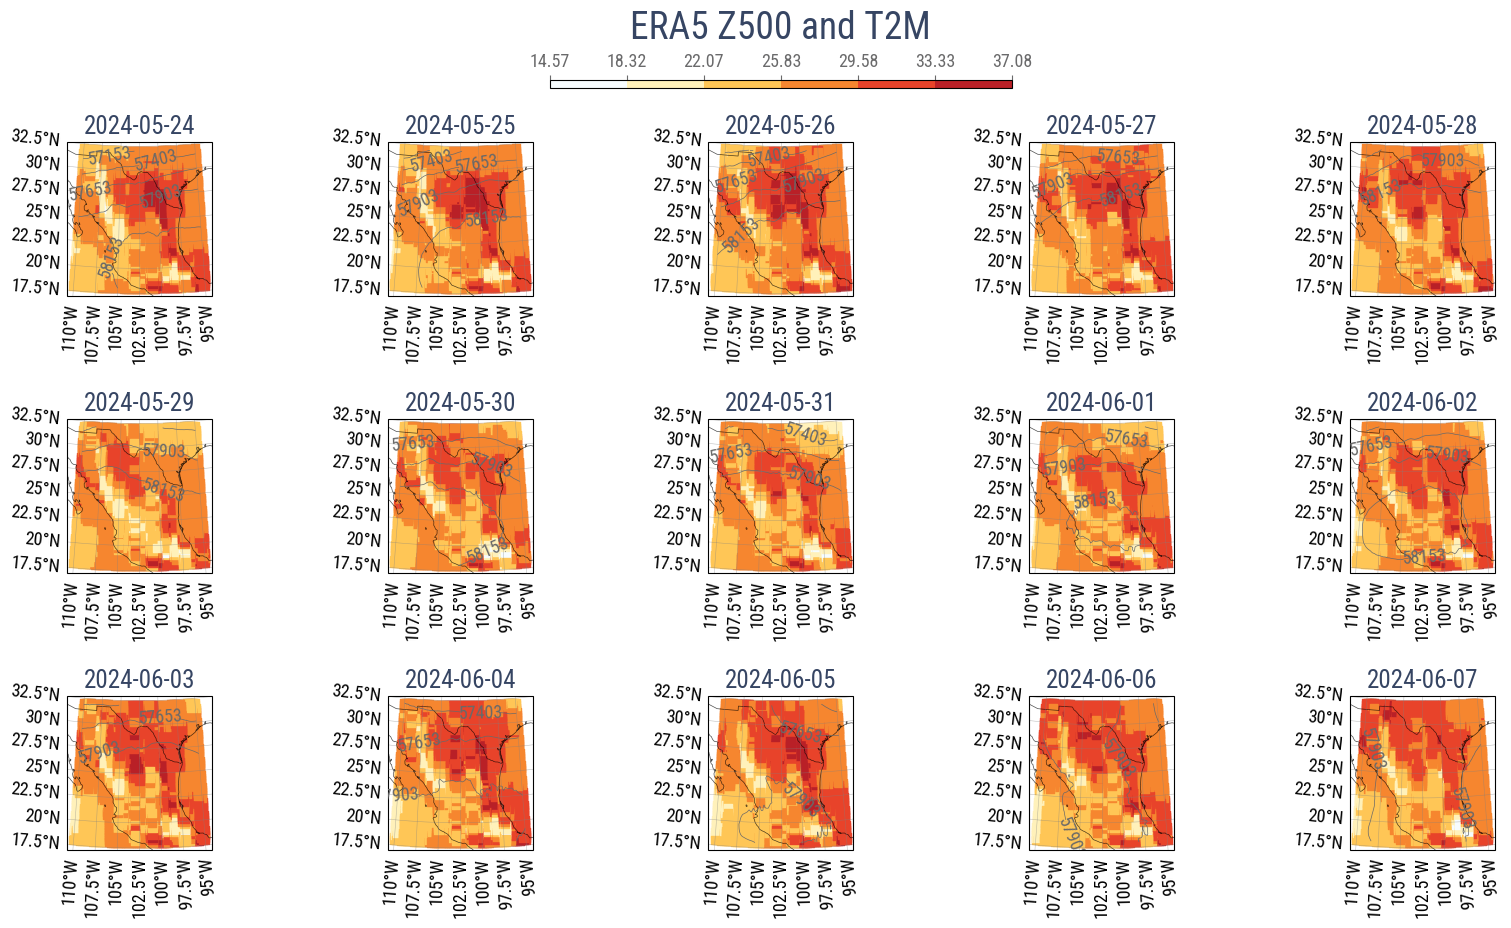

In [46]:
fig = subplot_contours(contour_gdf, gr_daily_eventNdays, datetime_col=datetime_col,
                      value_col=value_col, contour_col=contour_col, ncols=5,
                      contour_steps=contour_steps, legend_title=legend_title)

## 2.14 Describe the event and meteorology in the scientific seport Introduction

- a. Describe meteorological situation, using maps created in Step 2.13 and the event maps
created in Step 2.11
- b. Use information from seasonality
- c. Placeholder step to include a more elaborate event description by C3S, based on event
monitoring
- d. Placeholder step to include a more elaborate event description by local NMS

## 2.15 Spation pattern: calculate and save the monthly climatology field to be used for model validation

### <font color='orange'>Please specify the following variables to plot the monthly climatology</font>

In [47]:
# automatically selects the month(s) of the event, can be overwritten by user
month_range=(event_start.month, event_end.month)

title = "Temperature climatology mean June"

y_label = "(°C)"

dpi = 150

### Run code block

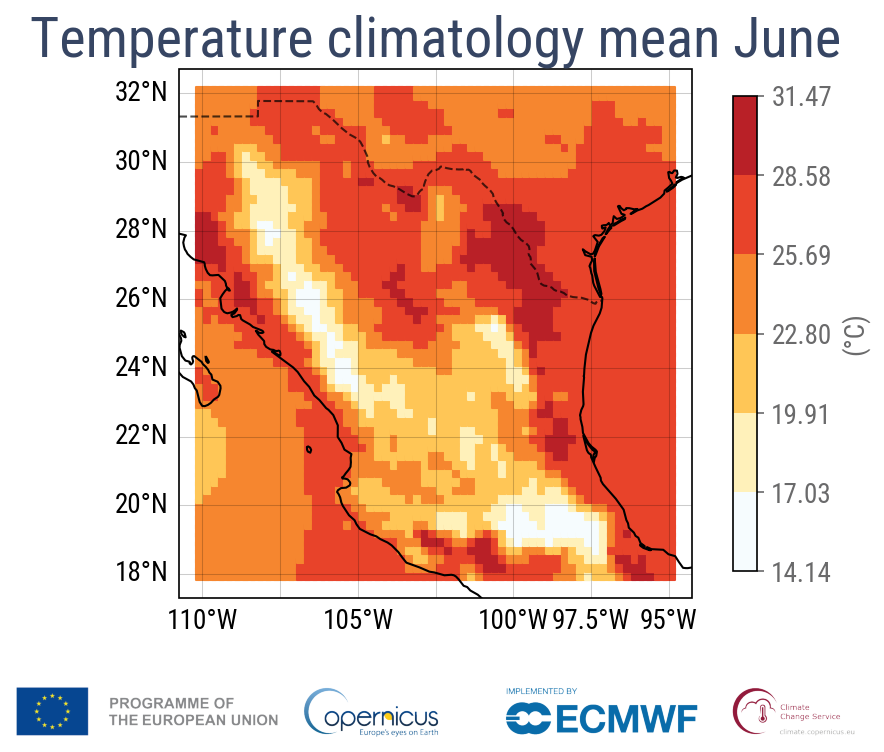

In [48]:
# select subset use the unsmoothed???
month_gdf = subset_gdf(gdf=clim31d, datetime_col=datetime_col,
                       year_range=(event_end.year, event_end.year),
                       month_range=month_range)
# calulate average
monthly_avg_gdf = calculate_mean(gdf=month_gdf, value_col=value_col, groupby_col=['longitude', 'latitude', 'geometry'])

# plot
fig, ax, img_ax = plot_gdf(monthly_avg_gdf, title=title,
                           legend_title=y_label,value_col=value_col, dpi=dpi)

### <font color='orange'>Please specify name for saving the monthly climatology</font>

In [49]:
monthly_avg_gdf_save = "mean_temperature_june"

monthly_avg_figure_sace = "mean_temperature_june"

### Run code block

In [50]:
monthly_avg_gdf.to_file(os.path.join(your_save_directory, f"{monthly_avg_gdf_save}.gpkg"), layer='climatology', driver='GPKG')

fig.savefig(fname=os.path.join(your_save_directory, f"{monthly_avg_figure_sace}.png"), dpi=150, bbox_inches="tight")